In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("LAB06_09_cleaned_retail_sample.csv")  
df.head()

,order_id,order_date,customer_id,gender,region,category,product,quantity,unit_price,discount,customer_age,status,order_month,revenue,age_group
0,O001,2025-01-03,C001,male,North,Technology,Laptop,1,1250.0,0.05,35.0,Delivered,2025-01,1187.50,36-50
1,O002,2025-01-05,C002,male,South,Furniture,Office Chair,2,180.0,0.10,42.0,Delivered,2025-01,324.00,36-50
2,O003,2025-01-07,C003,male,North,Office Supplies,Printer Paper,5,12.5,0.00,NaN,Delivered,2025-01,62.50,Unknown
3,O004,2025-01-09,C004,female,Central,Technology,Headset,3,45.0,0.05,29.0,Delayed,2025-01,128.25,26-35
4,O005,2025-01-11,C005,female,South,Furniture,Desk,1,350.0,0.15,31.0,Delivered,2025-01,297.50,26-35


In [2]:
group_var = "category"
num_var = "revenue"

grouped = df.groupby(group_var)[num_var].agg(
    count="count", mean="mean", median="median", std="std"
).round(2).reset_index()

grouped

,category,count,mean,median,std
0,Furniture,5,369.88,324.00,231.06
1,Office Supplies,4,43.88,41.50,14.55
2,Technology,6,402.92,266.52,431.20


In [3]:
grouped["comment"] = grouped["count"].apply(
    lambda n: "⚠️ Nhóm quá nhỏ (n<5), không nên so sánh mạnh" if n < 5
    else "Đủ để so sánh cơ bản, vẫn nên thận trọng" if n < 10
    else "Kích thước nhóm hợp lý"
)
grouped

,category,count,mean,median,std,comment
0,Furniture,5,369.88,324.00,231.06,"Đủ để so sánh cơ bản, vẫn nên thận trọng"
1,Office Supplies,4,43.88,41.50,14.55,"⚠️ Nhóm quá nhỏ (n<5), không nên so sánh mạnh"
2,Technology,6,402.92,266.52,431.20,"Đủ để so sánh cơ bản, vẫn nên thận trọng"


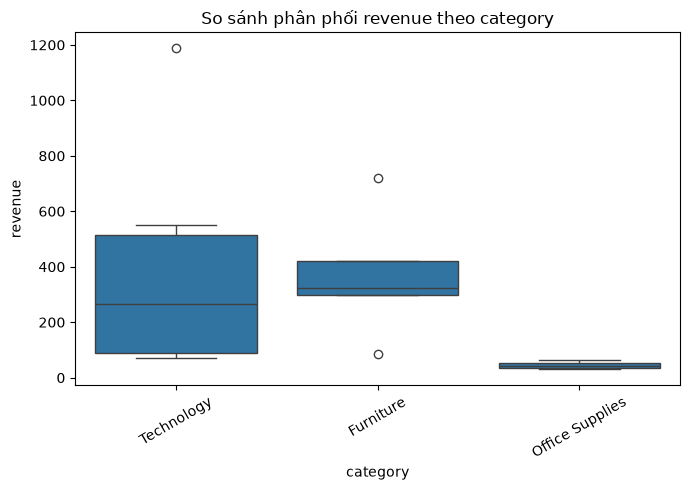

In [4]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x=group_var, y=num_var, ax=ax)
ax.set_title(f"So sánh phân phối {num_var} theo {group_var}")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("lab06_group_comparison.png", dpi=150)
plt.show()

## Từ boxplot: 
* Technology và Furniture có mean/median cao hơn hẳn Office Supplies (gấp gần 10 lần), nhưng đây là điểm cần thận trọng: dataset tổng chỉ có 15 dòng, chia thành 3 nhóm thì mỗi nhóm chỉ còn 4-6 quan sát — quá nhỏ để khẳng định chắc chắn sự khác biệt giữa các category là hệ thống (systematic) chứ không phải do vài điểm dữ liệu ngẫu nhiên.
* Đáng chú ý là std của Technology (431.20) cao gần gấp đôi mean của nó — điều này phản ánh đúng outlier trên boxplot (điểm ~1187.5, đúng là đơn Technology giá 1250 → revenue 1187.5). Nghĩa là "Technology có revenue cao nhất" phần lớn bị kéo bởi 1-2 đơn hàng giá trị rất lớn, chứ không phải cả nhóm đều cao. Median (266.52) thấp hơn mean (402.92) khá nhiều càng xác nhận điều này — dùng median sẽ phản ánh "case điển hình" chính xác hơn mean ở đây.
* Furniture cũng có hiện tượng tương tự nhưng nhẹ hơn (điểm ~720 kéo mean lên so với median 324).
* Office Supplies là nhóm ổn định nhất — std chỉ 14.55, mean ≈ median (43.88 vs 41.50) — cho thấy các đơn hàng trong nhóm này khá đồng đều về giá trị, nhưng đồng thời đây cũng là nhóm có ít quan sát nhất (n=4) nên kết luận "ổn định" này vẫn cần thêm dữ liệu để xác nhận.

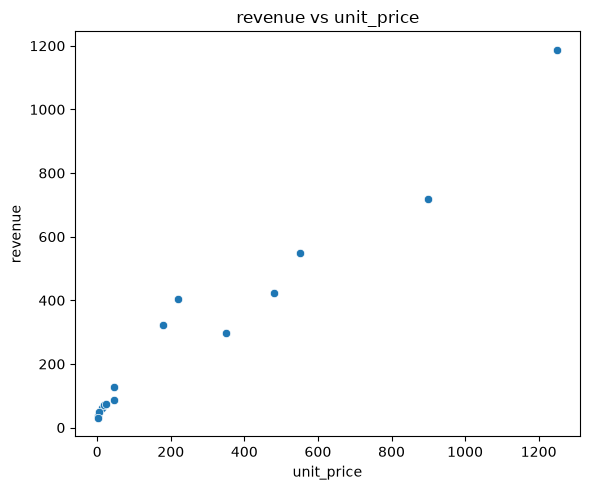

Correlation (unit_price, revenue) = 0.979


In [ ]:
x_var, y_var = "unit_price", "revenue"  

fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=df, x=x_var, y=y_var, ax=ax)
ax.set_title(f"{y_var} vs {x_var}")
plt.tight_layout()
plt.savefig("lab06_scatter.png", dpi=150)
plt.show()

corr = df[[x_var, y_var]].corr().iloc[0,1]
print(f"Correlation ({x_var}, {y_var}) = {corr:.3f}")

* Revenue trung bình cao nhất ở nhóm Technology (402.92) và Furniture (369.88), thấp nhất ở Office Supplies (43.88). 
* Tuy nhiên mỗi nhóm chỉ có 4-6 quan sát nên sự khác biệt này cần được xem là sơ bộ, chưa đủ mạnh để kết luận chắc chắn. 
* Ở nhóm Technology, std rất cao (431.20) so với mean cho thấy một vài đơn hàng giá trị lớn (như đơn revenue ~1187.5) đang kéo lệch trung bình; median (266.52) phản ánh case điển hình tốt hơn. 
* Hệ số tương quan giữa unit_price và revenue rất cao (r=0.979), phản ánh mối quan hệ gần tuyến tính — điều này phần lớn xuất phát từ việc revenue được tính trực tiếp từ unit_price × quantity, nên đây là mối quan hệ mang tính công thức hơn là một insight hành vi khách hàng. 

* --> Vì vậy, correlation cao ở đây không chứng minh quan hệ nhân quả kinh doanh, và với cỡ mẫu nhỏ (n=15), mọi kết luận trên chỉ mang tính minh họa ban đầu, cần thêm dữ liệu để kiểm chứng.